<h1> <b> Celebrity Face Recognition </b> </h1>

<h2> Overview </h2>

<p>In this project we'll create a pipeline using the VGGFace (Pre-trained) model to classify celebrity faces. We'll start with the following 8 classes and may expand it later on:<p>

<ul>
<li> Alexandra Daddario </li>
<li> Anne Hathaway </li>
<li> Emilia Clarke </li>
<li> Leonardo DiCaprio </li>
<li> Megan Fox </li>
<li> Robert Downey Jr. </li>
<li> Margot Robbie </li>
<li> Scarlett Johansson </li>
<li> Zaid Bin Zaheer </li>
<li> Sharjeel Ahmed </li>
</ul>

<h2> Inputs </h2>

<p> We'll use the following assets for training and evaluation of our model: <p>

<ul>
    <li> <b> Pins Face Recognition </b> dataset by <i> hereisburak </i></li>
    <li> <b> Vgg Face Weights </b> by <i> evertwydoodt </i> </li>
    <li> <b> Vgg Face Test </b> dataset by <i> zaidbinzaheerwater </i> </li>
    <li> <b> my-dataset </b> </li> dataset by <i> zaidbinzaheerwater </i> </li>
</ul>

<h2> Let's start </h2>

<h4>1. Importing Libraries </h4>

In [1]:
!pip install mtcnn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 60.6 MB/s eta 0:00:00


In [2]:
import os
import cv2
import random
import kagglehub
import numpy as np
from tqdm import tqdm
from mtcnn import MTCNN
import tensorflow as tf
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from tensorflow.keras.layers import * 
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.models import Sequential, Model
from sklearn.preprocessing import LabelEncoder, RobustScaler

2025-05-28 03:55:04.646995: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748404504.833642      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748404504.889415      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


<h4> 2. Loading the Dataset </h4>

<h5>2.1 Defining Constants</h5>

In [3]:
INPUT_DIR = r"/kaggle/input"
TRAIN_DIR = os.path.join(INPUT_DIR, "pins-face-recognition/105_classes_pins_dataset")
WEIGHTS_DIR = os.path.join(INPUT_DIR, "vgg-face-weights")
TEST_DIR = os.path.join(INPUT_DIR, "vgg-face-test")
EXTENDED_TRAIN_DIR = os.path.join(INPUT_DIR, "my-dataset/Train")
EXTENDED_TEST_DIR = os.path.join(INPUT_DIR, "my-dataset/Test")

IMG_H = 224
IMG_W = 224
IMG_SIZE = (IMG_H, IMG_W)
IMG_SHAPE = IMG_SIZE + (3, )
EMBEDDING_SIZE = 128

<h5>2.3. Filtering the Dataset</h5>
<p>The Pins Face Recognition has 105 Identities, we will start by filtering out the ones that have the most images and those who are well known</p>

In [4]:
filtered_celebs = [train_celeb for train_celeb in os.listdir(TRAIN_DIR) if train_celeb[5:].lower() in [test_celeb.lower() for test_celeb in os.listdir(TEST_DIR)] ]
filtered_celebs

['pins_Anne Hathaway',
 'pins_Emilia Clarke',
 'pins_Leonardo DiCaprio',
 'pins_Megan Fox',
 'pins_Robert Downey Jr',
 'pins_scarlett johansson',
 'pins_Alexandra Daddario',
 'pins_margot robbie']

In [5]:
image_count = {label:len(os.listdir(os.path.join(TRAIN_DIR, label))) for label in filtered_celebs}
our_image_count = {label:len(os.listdir(os.path.join(EXTENDED_TRAIN_DIR, label))) for label in os.listdir(EXTENDED_TRAIN_DIR)}
our_image_count

{'pins_Zaid': 317, 'pins_Sharjeel': 232}

<h5>2.4. Creating a Class to Store Image Metadata</h5>

In [6]:
class IdentityMetadata():
    def __init__(self, path, label, file_name):
        self.path = path
        self.original_label = label
        self.label = label.lower()
        
        self.file_name = file_name

    def __repr__(self):
        return self.image_path()

    def image_path(self):
        return os.path.join(self.path, self.original_label, self.file_name) 

<h5>2.5. Loading Metadata</h5>

In [7]:
def load_metadata(path, filters = []):
    metadata = []
    source_list = os.listdir(path)
    if len(filters) > 0:
        source_list = filters
    for i in source_list:
        for f in os.listdir(os.path.join(path, i)):
            metadata.append(IdentityMetadata(path, i, f))
    metadata = np.array(metadata)
    np.random.shuffle(metadata)
    return metadata

celeb_metadata = load_metadata(TRAIN_DIR, filtered_celebs)
our_metadata = load_metadata(EXTENDED_TRAIN_DIR)
metadata = np.concatenate((celeb_metadata, our_metadata), axis = 0)
metadata.shape

(2288,)

<h5> 2.6. Image Preprocessing Functions </h5>

In [8]:
detector = MTCNN()
def _crop_face_np(img_np):
    results = detector.detect_faces(img_np)
    if results:
        x, y, w, h = results[0]['box']
        x, y = max(0, x), max(0, y)
        return img_np[y:y+h, x:x+w]
    else:
        return img_np

def crop_face_tf(img):
    face = tf.py_function(
        func=_crop_face_np,
        inp=[img],
        Tout=tf.uint8
    )
    face.set_shape([None, None, 3])
    return face

def preprocess_image(img_path, label, crop_face=False):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.cast(img, tf.uint8)

    if crop_face:
        img = crop_face_tf(img)

    img = tf.image.resize(img, [IMG_H, IMG_W])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

I0000 00:00:1748404519.846607      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1748404519.847353      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


<h5> 2.7. Splitting Dataset into Training & Validation Sets</h5>

In [9]:
from sklearn.model_selection import train_test_split
paths = np.array([m.image_path() for m in metadata])
labels = np.array([m.label for m in metadata])
X_train, X_val, y_train, y_val = train_test_split(paths, labels, random_state = 42, test_size = 0.15,stratify = labels )
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((1944,), (344,), (1944,), (344,))

<h5> 2.8. Label Encoder for integer encoding of labels</h5>

In [10]:
le = LabelEncoder()
train_le = le.fit_transform(y_train)
val_le = le.transform(y_val)

<h4>3. Our Model</h4>

<h5>3.1. Defining Model Architecture</h5>
<p>We'll use the weights of VGGFace thus essentially skipping the training process.</p>

In [11]:
def vgg_face_model():	
    model = Sequential()
    model.add(ZeroPadding2D((1,1),input_shape=(224,224, 3)))
    model.add(Convolution2D(64, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(128, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(256, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(256, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(256, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(Convolution2D(4096, (7, 7), activation='relu'))
    model.add(Dropout(0.5))
    model.add(Convolution2D(4096, (1, 1), activation='relu'))
    model.add(Dropout(0.5))
    model.add(Convolution2D(2622, (1, 1)))
    model.add(Flatten())
    model.add(Activation('softmax'))
    return model
vgg_face = vgg_face_model()
vgg_face.load_weights(os.path.join(WEIGHTS_DIR, "vgg_face_weights.h5"))
vgg_face.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/zero_padding2d.py:72: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ zero_padding2d (ZeroPadding2D)       │ (None, 226, 226, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ zero_padding2d_1 (ZeroPadding2D)     │ (None, 226, 226, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ zero_padding2d_2 (ZeroPadding2D)     │ (None, 114, 114, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ zero_padding2d_3 (ZeroPadding2D)     │ (None, 114, 114, 128)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ zero_padding2d_4 (ZeroPadding2D)     │ (None, 58, 58, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ zero_padding2d_5 (ZeroPadding2D)     │ (None, 58, 58, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ zero_padding2d_6 (ZeroPadding2D)     │ (None, 58, 58, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ zero_padding2d_7 (ZeroPadding2D)     │ (None, 30, 30, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ zero_padding2d_8 (ZeroPadding2D)     │ (None, 30, 30, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 145,002,878 (553.14 MB)

 Trainable params: 145,002,878 (553.14 MB)

 Non-trainable params: 0 (0.00 B)

<h5>3.2. Creating tensorflow datasets from train and validation metadata sets</h5>

In [12]:
train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_train, train_le))
    .map(lambda x, y: preprocess_image(x, y, False), num_parallel_calls=tf.data.AUTOTUNE)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    tf.data.Dataset.from_tensor_slices((X_val, val_le))
    .map(lambda x, y: preprocess_image(x, y, False), num_parallel_calls=tf.data.AUTOTUNE)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

<h5> 3.3. Verifying the dataset to ensure images are loaded correctly</h5>

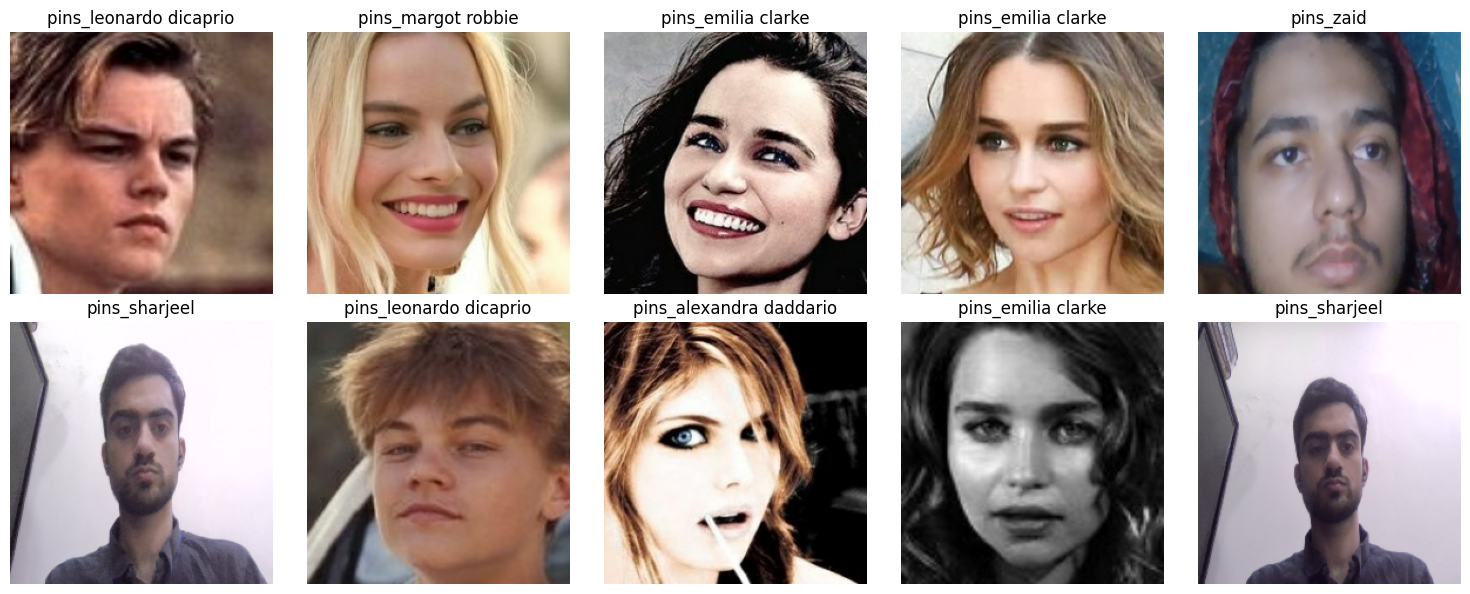

In [13]:
def show_sample_images(dataset, class_names=None, num_images=10):
    plt.figure(figsize=(15, 6))
    count = 0

    for images, labels in dataset:
        images = images.numpy()
        labels = labels.numpy()
        
        for i in range(5, len(images)):
            if count >= num_images:
                break

            plt.subplot(2, 5, count + 1)
            plt.imshow((images[i] * 255).astype("uint8"))
            label_idx = np.argmax(labels[i]) if len(labels[i].shape) > 0 and labels[i].ndim > 0 else labels[i]
            label_name = class_names[label_idx] if class_names is not None else str(label_idx)
            plt.title(label_name)
            plt.axis('off')
            count += 1

        if count >= num_images:
            break

    plt.tight_layout()
    plt.show()

class_names = le.inverse_transform(range(len(le.classes_)))
show_sample_images(val_dataset, class_names)

<h5>3.4. Creating a sub-model to extract embeddings from vgg-face model </h5>

In [14]:
embedding_model = Model(inputs=vgg_face.layers[0].input, outputs=vgg_face.layers[-2].output)

<h5> 3.5. Creating embeddings for training from train dataset</h5>

In [15]:
X_train_embeddings = embedding_model.predict(train_dataset)

I0000 00:00:1748404528.978161      70 service.cc:148] XLA service 0x78a19c00df80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748404528.978818      70 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1748404528.978834      70 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1748404529.112236      70 cuda_dnn.cc:529] Loaded cuDNN version 90300


 2/61 ━━━━━━━━━━━━━━━━━━━━ 8s 148ms/step 

I0000 00:00:1748404541.599650      70 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


61/61 ━━━━━━━━━━━━━━━━━━━━ 32s 314ms/step


<h5> 3.6. Creating embeddings for validation from validation dataset</h5>

In [16]:
X_val_embeddings = embedding_model.predict(val_dataset)

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 162ms/step


In [17]:
X_train_embeddings.shape, X_val_embeddings.shape

((1944, 2622), (344, 2622))

<h4>4. Predictions Using SVC Classifier</h4>

<p>We've calculted the embeddings for each image in the dataset. Now we'll get the embedding of the new image with our face recognition model and use svc classifier to predict the class of new image.</p>

<h5>4.1. Creating a pipeline for preprocessing and prediction</h5>

In [18]:
from sklearn.preprocessing import StandardScaler
pipeline = make_pipeline(
    StandardScaler(),        
    PCA(n_components= 128),
    SVC(C = 1.0, kernel='rbf', gamma='scale', probability=True)
)

In [19]:
pipeline.fit(X_train_embeddings, train_le)
print(f"Validation accuracy {pipeline.score(X_val_embeddings, val_le)}")

Validation accuracy 0.9941860465116279


<h4>5. Predictions on Test Data</h5>

<h5>5.1. Loading Test Data</h4>

In [20]:
celeb_test = load_metadata(TEST_DIR)
our_test = load_metadata(EXTENDED_TEST_DIR)
test_metadata = np.concatenate((celeb_test, our_test), axis = 0)
test_metadata.shape

(50,)

<h5>5.2. Creating Test Dataset</h5>

In [21]:
test_images = np.array([m.image_path() for m in test_metadata])
labels = np.array([f"pins_{m.label}" for m in test_metadata])
encoded_labels = le.transform(labels)
test_dataset = tf.data.Dataset.from_tensor_slices((test_images, encoded_labels)) \
    .map(lambda x, y: preprocess_image(x, y, crop_face=True), num_parallel_calls=tf.data.AUTOTUNE) \
    .batch(32) \
    .prefetch(tf.data.AUTOTUNE)



<h5>5.3. Generating Test Embeddings</h5>

In [22]:
test_embeddings = embedding_model.predict(test_dataset)

2/2 ━━━━━━━━━━━━━━━━━━━━ 16s 12s/step


In [23]:
test_embeddings.shape

(50, 2622)

<h5>5.4. Prediction of test data</h5>

In [24]:
y_test_pred = pipeline.predict(test_embeddings)

In [25]:
accuracy_score(y_test_pred, encoded_labels)

0.9

<h5>5.5. Exporting Models</h5>

In [26]:
import joblib
joblib.dump({ 'pipeline': pipeline, 'le': le }, 'face_rec.pkl')

model.save(r"/kaggle/working/embedding_model.keras")

NameError: name 'model' is not defined